# 1. What is Chunking?

**Chunking is the process of dividing large data into smaller, meaningful units called chunks.**

In a RAG pipeline, each chunk can be:

- Embedded separately
- Stored separately
- Retrieved separately
- Sent to an LLM only when relevant

### Basic flow

```text
Large document
      ↓
Chunking
      ↓
Chunk 1, Chunk 2, Chunk 3...
      ↓
Embeddings and retrieval
      ↓
Relevant chunks sent to the LLM
```

## Simple example

Suppose the original document contains three topics:

```text
Section 1: What is artificial intelligence?
Section 2: What is machine learning?
Section 3: What is deep learning?
```

Instead of storing the complete document as one unit, we can create:

```text
Chunk 1 → Artificial intelligence section
Chunk 2 → Machine learning section
Chunk 3 → Deep learning section
```

A question about machine learning can then retrieve only Chunk 2.

# 2. Why Do We Need Chunking?

##### 2.1 LLM context-window limitations

Every LLM has a maximum input capacity. A very large document may not fit inside one request.

#####2.2 Better retrieval accuracy

A small relevant section is easier to retrieve than one huge document containing many unrelated topics.

##### 2.3 Lower token usage and cost

Only relevant chunks need to be sent to the LLM.

##### 2.4 Faster processing

Smaller units are easier to embed, index, retrieve, and process.

##### 2.5 Sending only relevant information

The LLM receives focused context instead of the entire knowledge base.

### Important balance

- Very small chunks may lose context.
- Very large chunks may contain irrelevant information.
- Excessive overlap creates duplication and increases storage and token usage.

# 3. Is Chunking Always Required?

No. Chunking is a design choice, not a compulsory step.

## Chunking is usually required when:

- The document is large
- The document exceeds the model context window
- Semantic retrieval is required
- Different sections discuss different topics
- Only a small section should be sent to the LLM
- The source is a long PDF, manual, policy, or knowledge base

## Chunking may not be required when:

- The input is already short
- One complete record is already a meaningful unit
- SQL can retrieve exact rows
- The full document is required for the task
- The complete input comfortably fits inside the model context
- The data is already separated into FAQs, tickets, products, or database records

# 4. Different Ways of Chunking

| Method | Main idea | Good for |
|---|---|---|
| Fixed-size | Divide by a fixed character or token length | Predictable sizing |
| Recursive | Try paragraphs, lines, words, then characters | General text and PDFs |
| Sentence-based | Preserve sentence boundaries | Natural-language content |
| Paragraph-based | Keep complete paragraphs together | Articles and reports |
| Token-based | Measure chunks using model tokens | Strict model limits |
| Semantic | Split when topic or meaning changes | Topic-heavy documents |
| Structure-based | Use headings, tags, sections, or JSON hierarchy | Markdown, HTML, JSON |
| Parent-child | Retrieve small child chunks and return larger parent context | Long manuals and policies |
| Agentic/LLM-based | Let an LLM identify meaningful boundaries | Complex and irregular content |

# 5. Chunking Methods Available in LangChain

The following practical examples use:

- `CharacterTextSplitter`
- `RecursiveCharacterTextSplitter`
- `TokenTextSplitter`
- `MarkdownHeaderTextSplitter`
- `HTMLHeaderTextSplitter`
- `RecursiveJsonSplitter`
- `PythonCodeTextSplitter`
- `NLTKTextSplitter`

For most general text-based RAG use cases, begin with `RecursiveCharacterTextSplitter` and adjust only after evaluating retrieval quality.

In [2]:
!uv pip install -q langchain-text-splitters

In [3]:
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter,
    TokenTextSplitter,
    MarkdownHeaderTextSplitter,
    HTMLHeaderTextSplitter,
    RecursiveJsonSplitter,
    PythonCodeTextSplitter,
    NLTKTextSplitter,
)

In [5]:
sample_text = """
Chunking is an important data preparation step in retrieval-augmented generation.
It divides large documents into smaller units that can be embedded and retrieved.

A good chunk should contain enough context to be understandable independently.
However, it should not be so large that unrelated topics are mixed together.

Chunk size controls the maximum length of a chunk.
Chunk overlap repeats some content between neighboring chunks and can protect
information located near a boundary.

The correct chunking strategy depends on the document type, structure, model,
embedding limits, retrieval requirements, and expected user questions.
""".strip()

from typing import Any
def print_chunks(
    name: str,
    chunks: list[Any],
    max_preview: int = 180,
) -> None:
    print(f"\n{'=' * 70}")
    print(name)
    print(f"Total chunks: {len(chunks)}")
    print("=" * 70)

    for index, chunk in enumerate(chunks, start=1):
        content = getattr(chunk, "page_content", str(chunk))
        metadata = getattr(chunk, "metadata", {})

        preview = content.replace("\n", " ")
        if len(preview) > max_preview:
            preview = preview[:max_preview] + "..."

        print(f"Chunk {index} | length={len(content)}")
        if metadata:
            print("Metadata:", metadata)
        print(preview)
        print("-" * 70)

## `CharacterTextSplitter`

This splitter divides text using one selected separator.

It is simple, but if a separator-delimited section is already larger than the requested size, the result may not always behave like a strict fixed-width slicer.

In [6]:
character_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=220,
    chunk_overlap=30,
    length_function=len,
)

character_chunks = character_splitter.split_text(sample_text)  # split text when use when i have plan text then use and this is not add metadata
print_chunks("CharacterTextSplitter", character_chunks)


CharacterTextSplitter
Total chunks: 4
Chunk 1 | length=163
Chunking is an important data preparation step in retrieval-augmented generation. It divides large documents into smaller units that can be embedded and retrieved.
----------------------------------------------------------------------
Chunk 2 | length=155
A good chunk should contain enough context to be understandable independently. However, it should not be so large that unrelated topics are mixed together.
----------------------------------------------------------------------
Chunk 3 | length=165
Chunk size controls the maximum length of a chunk. Chunk overlap repeats some content between neighboring chunks and can protect information located near a boundary.
----------------------------------------------------------------------
Chunk 4 | length=148
The correct chunking strategy depends on the document type, structure, model, embedding limits, retrieval requirements, and expected user questions.
-----------------------------

## `RecursiveCharacterTextSplitter`

It tries separators in order, normally preserving larger units first:

```text
Paragraph → line → word → character
```

In [7]:
recursive_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=220,
    chunk_overlap=30,
    length_function=len,
    add_start_index=True,
)

recursive_documents = recursive_splitter.create_documents( # create documents mean make a langchain Document object from the text and you can add metadata
    [sample_text],
    metadatas=[{"source": "class_sample.txt"}],
)

print_chunks(
    "RecursiveCharacterTextSplitter",
    recursive_documents,
)


RecursiveCharacterTextSplitter
Total chunks: 4
Chunk 1 | length=163
Metadata: {'source': 'class_sample.txt', 'start_index': 0}
Chunking is an important data preparation step in retrieval-augmented generation. It divides large documents into smaller units that can be embedded and retrieved.
----------------------------------------------------------------------
Chunk 2 | length=155
Metadata: {'source': 'class_sample.txt', 'start_index': 165}
A good chunk should contain enough context to be understandable independently. However, it should not be so large that unrelated topics are mixed together.
----------------------------------------------------------------------
Chunk 3 | length=165
Metadata: {'source': 'class_sample.txt', 'start_index': 322}
Chunk size controls the maximum length of a chunk. Chunk overlap repeats some content between neighboring chunks and can protect information located near a boundary.
----------------------------------------------------------------------
Chunk 4 |

## `TokenTextSplitter`

This method measures and splits content using tokenizer tokens rather than character count.

Use the same or a compatible tokenizer as the target model whenever possible.

In [8]:
token_splitter = TokenTextSplitter(
    encoding_name="cl100k_base",
    chunk_size=45,
    chunk_overlap=8,
)

token_chunks = token_splitter.split_text(sample_text)
print_chunks("TokenTextSplitter", token_chunks)


TokenTextSplitter
Total chunks: 3
Chunk 1 | length=262
Chunking is an important data preparation step in retrieval-augmented generation. It divides large documents into smaller units that can be embedded and retrieved.  A good chunk sh...
----------------------------------------------------------------------
Chunk 2 | length=267
 be understandable independently. However, it should not be so large that unrelated topics are mixed together.  Chunk size controls the maximum length of a chunk. Chunk overlap rep...
----------------------------------------------------------------------
Chunk 3 | length=203
 and can protect information located near a boundary.  The correct chunking strategy depends on the document type, structure, model, embedding limits, retrieval requirements, and e...
----------------------------------------------------------------------


## `MarkdownHeaderTextSplitter`

This structure-aware splitter uses Markdown headings and keeps heading information in metadata.

In [10]:
markdown_text = """
# RAG

Retrieval-augmented generation combines retrieval with generation.

## Chunking

Chunking divides large documents into smaller units.

### Chunk Size

Chunk size controls how much information is stored in one chunk.

### Chunk Overlap

Overlap repeats some information across neighboring chunks.

## Retrieval

Retrieval selects the chunks relevant to a user question.
""".strip()

In [11]:
markdown_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
    ]
)

markdown_chunks = markdown_splitter.split_text(markdown_text)
print_chunks("MarkdownHeaderTextSplitter", markdown_chunks)


MarkdownHeaderTextSplitter
Total chunks: 5
Chunk 1 | length=66
Metadata: {'Header 1': 'RAG'}
Retrieval-augmented generation combines retrieval with generation.
----------------------------------------------------------------------
Chunk 2 | length=52
Metadata: {'Header 1': 'RAG', 'Header 2': 'Chunking'}
Chunking divides large documents into smaller units.
----------------------------------------------------------------------
Chunk 3 | length=64
Metadata: {'Header 1': 'RAG', 'Header 2': 'Chunking', 'Header 3': 'Chunk Size'}
Chunk size controls how much information is stored in one chunk.
----------------------------------------------------------------------
Chunk 4 | length=59
Metadata: {'Header 1': 'RAG', 'Header 2': 'Chunking', 'Header 3': 'Chunk Overlap'}
Overlap repeats some information across neighboring chunks.
----------------------------------------------------------------------
Chunk 5 | length=57
Metadata: {'Header 1': 'RAG', 'Header 2': 'Retrieval'}
Retrieval selects the chu

## `HTMLHeaderTextSplitter`

This splitter uses HTML heading tags such as `<h1>`, `<h2>`, and `<h3>`.

In [12]:
html_text = """
<html>
  <body>
    <h1>RAG</h1>
    <p>RAG combines retrieval and generation.</p>

    <h2>Chunking</h2>
    <p>Chunking divides a large source into smaller units.</p>

    <h3>Overlap</h3>
    <p>Overlap protects information near chunk boundaries.</p>

    <h2>Retrieval</h2>
    <p>Retrieval selects relevant chunks for a question.</p>
  </body>
</html>
""".strip()

In [13]:
html_splitter = HTMLHeaderTextSplitter(
    headers_to_split_on=[
        ("h1", "Header 1"),
        ("h2", "Header 2"),
        ("h3", "Header 3"),
    ]
)

html_chunks = html_splitter.split_text(html_text)
print_chunks("HTMLHeaderTextSplitter", html_chunks)


HTMLHeaderTextSplitter
Total chunks: 8
Chunk 1 | length=3
Metadata: {'Header 1': 'RAG'}
RAG
----------------------------------------------------------------------
Chunk 2 | length=38
Metadata: {'Header 1': 'RAG'}
RAG combines retrieval and generation.
----------------------------------------------------------------------
Chunk 3 | length=8
Metadata: {'Header 1': 'RAG', 'Header 2': 'Chunking'}
Chunking
----------------------------------------------------------------------
Chunk 4 | length=51
Metadata: {'Header 1': 'RAG', 'Header 2': 'Chunking'}
Chunking divides a large source into smaller units.
----------------------------------------------------------------------
Chunk 5 | length=7
Metadata: {'Header 1': 'RAG', 'Header 2': 'Chunking', 'Header 3': 'Overlap'}
Overlap
----------------------------------------------------------------------
Chunk 6 | length=51
Metadata: {'Header 1': 'RAG', 'Header 2': 'Chunking', 'Header 3': 'Overlap'}
Overlap protects information near chunk boundaries.
--

## `RecursiveJsonSplitter`

This method divides nested JSON while preserving its hierarchy.

In [14]:
json_data = {
    "company": "Example AI",
    "departments": {
        "engineering": {
            "teams": ["platform", "ml", "data"],
            "description": (
                "Engineering builds and maintains the technology platform."
            ),
        },
        "sales": {
            "regions": ["North", "South", "East", "West"],
            "description": (
                "Sales manages customers and commercial relationships."
            ),
        },
    },
    "products": [
        {
            "name": "Document Assistant",
            "features": [
                "search",
                "summarization",
                "question answering",
            ],
        },
        {
            "name": "Analytics Assistant",
            "features": [
                "SQL generation",
                "chart explanation",
                "reporting",
            ],
        },
    ],
}

In [15]:
import json
json_splitter = RecursiveJsonSplitter(max_chunk_size=220)

json_chunks = json_splitter.split_json(
    json_data=json_data,
    convert_lists=True,
)

print("Total JSON chunks:", len(json_chunks))
for index, chunk in enumerate(json_chunks, start=1):
    print(f"\nJSON Chunk {index}")
    print(json.dumps(chunk, indent=2))

Total JSON chunks: 4

JSON Chunk 1
{
  "company": "Example AI",
  "departments": {
    "engineering": {
      "teams": {
        "0": "platform",
        "1": "ml",
        "2": "data"
      },
      "description": "Engineering builds and maintains the technology platform."
    }
  }
}

JSON Chunk 2
{
  "departments": {
    "sales": {
      "regions": {
        "0": "North",
        "1": "South",
        "2": "East",
        "3": "West"
      },
      "description": "Sales manages customers and commercial relationships."
    }
  }
}

JSON Chunk 3
{
  "products": {
    "0": {
      "name": "Document Assistant",
      "features": {
        "0": "search",
        "1": "summarization",
        "2": "question answering"
      }
    }
  }
}

JSON Chunk 4
{
  "products": {
    "1": {
      "name": "Analytics Assistant",
      "features": {
        "0": "SQL generation",
        "1": "chart explanation",
        "2": "reporting"
      }
    }
  }
}


## Code-aware chunking

`PythonCodeTextSplitter` attempts to split Python code at natural syntax boundaries.

In [16]:
python_code = '''
class DocumentProcessor:
    def load(self, path):
        print(f"Loading {path}")
        return "document content"

    def clean(self, text):
        return " ".join(text.split())

    def process(self, path):
        text = self.load(path)
        return self.clean(text)


def calculate_chunk_count(total_length, chunk_size):
    if chunk_size <= 0:
        raise ValueError("chunk_size must be positive")
    return (total_length + chunk_size - 1) // chunk_size
'''.strip()

In [17]:
code_splitter = PythonCodeTextSplitter(
    chunk_size=180,
    chunk_overlap=20,
)

code_chunks = code_splitter.split_text(python_code)
print_chunks("PythonCodeTextSplitter", code_chunks)


PythonCodeTextSplitter
Total chunks: 4
Chunk 1 | length=117
class DocumentProcessor:     def load(self, path):         print(f"Loading {path}")         return "document content"
----------------------------------------------------------------------
Chunk 2 | length=153
def clean(self, text):         return " ".join(text.split())      def process(self, path):         text = self.load(path)         return self.clean(text)
----------------------------------------------------------------------
Chunk 3 | length=132
def calculate_chunk_count(total_length, chunk_size):     if chunk_size <= 0:         raise ValueError("chunk_size must be positive")
----------------------------------------------------------------------
Chunk 4 | length=52
return (total_length + chunk_size - 1) // chunk_size
----------------------------------------------------------------------


## Sentence-based splitting with `NLTKTextSplitter`

This splitter uses NLTK sentence tokenization.

The first run may require downloading NLTK tokenizer data.

In [18]:
import nltk

# Depending on the installed NLTK version, both resources may be useful.
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

sentence_splitter = NLTKTextSplitter(
    chunk_size=220,
    chunk_overlap=20,
)

sentence_chunks = sentence_splitter.split_text(sample_text)
print_chunks("NLTKTextSplitter", sentence_chunks)


NLTKTextSplitter
Total chunks: 4
Chunk 1 | length=164
Chunking is an important data preparation step in retrieval-augmented generation.  It divides large documents into smaller units that can be embedded and retrieved.
----------------------------------------------------------------------
Chunk 2 | length=208
A good chunk should contain enough context to be understandable independently.  However, it should not be so large that unrelated topics are mixed together.  Chunk size controls th...
----------------------------------------------------------------------
Chunk 3 | length=114
Chunk overlap repeats some content between neighboring chunks and can protect information located near a boundary.
----------------------------------------------------------------------
Chunk 4 | length=148
The correct chunking strategy depends on the document type, structure, model, embedding limits, retrieval requirements, and expected user questions.
--------------------------------------------------------

#### Chunk Size and Chunk Overlap
## Teaching interpretation

- Smaller chunk size usually creates more chunks.
- Larger overlap usually increases repeated stored content.
- A larger chunk may preserve more context but reduce retrieval precision.
- A smaller chunk may improve precision but lose surrounding explanation.
- The best values must be evaluated using real questions and retrieval results.


# Parent-Child Chunking

Parent-child chunking keeps two levels:

- **Child chunks:** small and precise, used for retrieval
- **Parent chunks:** larger and richer, returned to the LLM

Example:

```text
Parent: Complete policy section
    ├── Child 1: Eligibility
    ├── Child 2: Required documents
    └── Child 3: Approval process
```

In [19]:
import pandas as pd

parent_splitter = RecursiveCharacterTextSplitter(
    chunk_size=420,
    chunk_overlap=40,
)

child_splitter = RecursiveCharacterTextSplitter(
    chunk_size=140,
    chunk_overlap=20,
)

parent_documents = parent_splitter.create_documents(
    [sample_text],
    metadatas=[{"source": "policy.txt"}],
)

parent_child_records = []

for parent_index, parent in enumerate(parent_documents, start=1):
    children = child_splitter.create_documents(
        [parent.page_content],
        metadatas=[
            {
                "source": "policy.txt",
                "parent_id": f"parent-{parent_index}",
            }
        ],
    )

    for child_index, child in enumerate(children, start=1):
        parent_child_records.append(
            {
                "parent_id": f"parent-{parent_index}",
                "child_id": f"parent-{parent_index}-child-{child_index}",
                "child_text": child.page_content,
                "parent_text": parent.page_content,
            }
        )

parent_child_df = pd.DataFrame(parent_child_records)
display(parent_child_df)

,parent_id,child_id,child_text,parent_text
0,parent-1,parent-1-child-1,Chunking is an important data preparation step...,Chunking is an important data preparation step...
1,parent-1,parent-1-child-2,It divides large documents into smaller units ...,Chunking is an important data preparation step...
2,parent-1,parent-1-child-3,A good chunk should contain enough context to ...,Chunking is an important data preparation step...
3,parent-1,parent-1-child-4,"However, it should not be so large that unrela...",Chunking is an important data preparation step...
4,parent-2,parent-2-child-1,Chunk size controls the maximum length of a ch...,Chunk size controls the maximum length of a ch...
5,parent-2,parent-2-child-2,information located near a boundary.,Chunk size controls the maximum length of a ch...
6,parent-2,parent-2-child-3,The correct chunking strategy depends on the d...,Chunk size controls the maximum length of a ch...
7,parent-2,parent-2-child-4,"embedding limits, retrieval requirements, and ...",Chunk size controls the maximum length of a ch...



# CONTENT-AWARE CHUNKING

- Idea: keep a paragraph whole if it already fits. Only break it into
 sentences when the paragraph itself is too big. Then merge small units
  back together until we reach the target size.

In [33]:
import re

In [34]:
document = """
# Artificial Intelligence

Artificial intelligence enables machines to perform tasks that normally require human intelligence.
AI systems can analyze information, identify patterns, and support decision-making.

## Machine Learning

Machine learning is a branch of artificial intelligence.
It enables systems to learn patterns from historical data instead of relying only on explicitly programmed rules.
Supervised learning uses labelled examples, while unsupervised learning discovers patterns in unlabelled data.

## Deep Learning

Deep learning uses neural networks containing multiple layers.
It is commonly applied to image recognition, speech processing, and natural-language applications.

# Employee Leave Policy

Employees receive twenty paid leave days during a calendar year.
Leave must be approved by the manager before the leave date.
"""

In [35]:
all_results = {}

def split_sentences(text):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s.strip()]


max_characters = 200

paragraphs = [p.strip() for p in document.split("\n\n") if p.strip()]

logical_units = []
for paragraph in paragraphs:
    if len(paragraph) <= max_characters:
        logical_units.append(paragraph)
    else:
        logical_units.extend(split_sentences(paragraph))

content_aware_chunks = []
current_units = []
current_length = 0

for unit in logical_units:
    separator_length = 2 if current_units else 0
    proposed_length = current_length + separator_length + len(unit)

    if proposed_length <= max_characters:
        current_units.append(unit)
        current_length = proposed_length
    else:
        if current_units:
            content_aware_chunks.append("\n\n".join(current_units))
        current_units = [unit]
        current_length = len(unit)

if current_units:
    content_aware_chunks.append("\n\n".join(current_units))

all_results["Content-aware"] = content_aware_chunks

print("=" * 90)
print("Content-Aware Chunking")
print("Total chunks:", len(content_aware_chunks))
print("=" * 90)
for i, c in enumerate(content_aware_chunks, 1):
    print(f"\nChunk {i} | characters={len(c)}\n{c}")

Content-Aware Chunking
Total chunks: 6

Chunk 1 | characters=25
# Artificial Intelligence

Chunk 2 | characters=183
Artificial intelligence enables machines to perform tasks that normally require human intelligence.
AI systems can analyze information, identify patterns, and support decision-making.

Chunk 3 | characters=192
## Machine Learning

Machine learning is a branch of artificial intelligence.

It enables systems to learn patterns from historical data instead of relying only on explicitly programmed rules.

Chunk 4 | characters=128
Supervised learning uses labelled examples, while unsupervised learning discovers patterns in unlabelled data.

## Deep Learning

Chunk 5 | characters=186
Deep learning uses neural networks containing multiple layers.
It is commonly applied to image recognition, speech processing, and natural-language applications.

# Employee Leave Policy

Chunk 6 | characters=125
Employees receive twenty paid leave days during a calendar year.
Leave must be approved

# Teacher Observation:
- Fixed-size chunking only asks "have we reached the size limit?"
- Content-aware chunking also asks "is this a natural place to break?"
- Notice a paragraph is never split unless it is already too large on
- its own — the heading "Employee Leave Policy" stays with its content.


# STRUCTURE-BASED + RECURSIVE (TWO-STAGE CHUNKING)
- Stage 1: split by Markdown headings (a heading-based section may
          still be too large for the model).
- Stage 2: recursively re-split any section that is still oversized.

In [36]:

markdown_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
    ],
    strip_headers=True,
)

header_documents = markdown_splitter.split_text(document)

secondary_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=20,
    separators=["\n\n", "\n", ". ", " ", ""],
)

structure_then_recursive = secondary_splitter.split_documents(header_documents)

all_results["Structure + recursive"] = structure_then_recursive

print("\n" + "=" * 90)
print("Structure-Based Splitting Followed by Recursive Splitting")
print("Total chunks:", len(structure_then_recursive))
print("=" * 90)
for i, doc in enumerate(structure_then_recursive, 1):
    print(f"\nChunk {i} | characters={len(doc.page_content)} | metadata={doc.metadata}")
    print(doc.page_content)


Structure-Based Splitting Followed by Recursive Splitting
Total chunks: 8

Chunk 1 | characters=99 | metadata={'Header 1': 'Artificial Intelligence'}
Artificial intelligence enables machines to perform tasks that normally require human intelligence.

Chunk 2 | characters=83 | metadata={'Header 1': 'Artificial Intelligence'}
AI systems can analyze information, identify patterns, and support decision-making.

Chunk 3 | characters=56 | metadata={'Header 1': 'Artificial Intelligence', 'Header 2': 'Machine Learning'}
Machine learning is a branch of artificial intelligence.

Chunk 4 | characters=113 | metadata={'Header 1': 'Artificial Intelligence', 'Header 2': 'Machine Learning'}
It enables systems to learn patterns from historical data instead of relying only on explicitly programmed rules.

Chunk 5 | characters=110 | metadata={'Header 1': 'Artificial Intelligence', 'Header 2': 'Machine Learning'}
Supervised learning uses labelled examples, while unsupervised learning discovers patterns i

# Teacher Observation:
- Stage 1 alone can still leave a section that is too big for the model.
- Stage 2 fixes that, while every resulting chunk KEEPS the heading
- metadata from Stage 1 (Header 1 / Header 2). This is why it is called
- a "two-stage" pattern rather than a single splitter.


# REAL SEMANTIC CHUNKING (sentence-window embeddings)

- Unlike Notebook 1 (which only described this in pseudocode), here we
- actually compute embeddings, measure distance between neighbouring
- sentence windows, and cut where the distance is unusually large.

In [39]:
import numpy as np
sentences = split_sentences(re.sub(r"\n+", " ", document))

buffer_size = 1
windows = []
for index in range(len(sentences)):
    start = max(0, index - buffer_size)
    end = min(len(sentences), index + buffer_size + 1)
    windows.append(" ".join(sentences[start:end]))

# Try a real sentence embedding model first; fall back to TF-IDF so the
# script still runs even without internet access / the extra package.
try:
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    embeddings = model.encode(windows, normalize_embeddings=True, show_progress_bar=False)
    embedding_method = "Sentence Transformers embeddings"
except Exception:
    from sklearn.feature_extraction.text import TfidfVectorizer

    vectorizer = TfidfVectorizer()
    embeddings = vectorizer.fit_transform(windows).toarray()
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms[norms == 0] = 1
    embeddings = embeddings / norms
    embedding_method = "TF-IDF fallback (not true semantic embeddings)"

similarities = np.sum(embeddings[:-1] * embeddings[1:], axis=1)
distances = 1 - similarities

breakpoint_percentile = 75
threshold = float(np.percentile(distances, breakpoint_percentile))

break_after_indices = {i for i, d in enumerate(distances) if d > threshold}

semantic_chunks = []
current_sentences = []
for i, sentence in enumerate(sentences):
    current_sentences.append(sentence)
    if i in break_after_indices:
        semantic_chunks.append(" ".join(current_sentences))
        current_sentences = []
if current_sentences:
    semantic_chunks.append(" ".join(current_sentences))

all_results["Semantic chunking"] = semantic_chunks

print("\n" + "=" * 90)
print("Semantic Chunking")
print("Embedding method:", embedding_method)
print("Distance threshold:", round(threshold, 4))
print("Total chunks:", len(semantic_chunks))
print("=" * 90)
for i, c in enumerate(semantic_chunks, 1):
    print(f"\nChunk {i} | characters={len(c)}\n{c}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Semantic Chunking
Embedding method: Sentence Transformers embeddings
Distance threshold: 0.2763
Total chunks: 3

Chunk 1 | characters=591
# Artificial Intelligence Artificial intelligence enables machines to perform tasks that normally require human intelligence. AI systems can analyze information, identify patterns, and support decision-making. ## Machine Learning Machine learning is a branch of artificial intelligence. It enables systems to learn patterns from historical data instead of relying only on explicitly programmed rules. Supervised learning uses labelled examples, while unsupervised learning discovers patterns in unlabelled data. ## Deep Learning Deep learning uses neural networks containing multiple layers.

Chunk 2 | characters=98
It is commonly applied to image recognition, speech processing, and natural-language applications.

Chunk 3 | characters=149
# Employee Leave Policy Employees receive twenty paid leave days during a calendar year. Leave must be approved by the 

# Teacher Observation:
- A HIGH distance between two neighbouring sentence windows means their
- meaning is very different — that is exactly where we cut.
- Lower percentile -> more cuts -> more, smaller chunks.
- Higher percentile -> fewer cuts -> fewer, larger chunks.
- Try changing breakpoint_percentile to 50 or 90 and re-run to see the
- chunk count change.


# QUANTITATIVE COMPARISON OF CHUNK STATISTICS

Simple size table: how many chunks, and how big are they, per method.

In [40]:
comparison_rows = []
for method, chunks in all_results.items():
    lengths = [len(getattr(c, "page_content", str(c))) for c in chunks]
    comparison_rows.append({
        "method": method,
        "number_of_chunks": len(chunks),
        "minimum_length": min(lengths) if lengths else 0,
        "maximum_length": max(lengths) if lengths else 0,
        "average_length": round(float(np.mean(lengths)), 2) if lengths else 0,
        "total_stored_characters": sum(lengths),
    })

comparison = pd.DataFrame(comparison_rows).sort_values("number_of_chunks").reset_index(drop=True)

print("\n" + "=" * 90)
print("Chunk Statistics Comparison")
print("=" * 90)
print(comparison.to_string(index=False))


Chunk Statistics Comparison
               method  number_of_chunks  minimum_length  maximum_length  average_length  total_stored_characters
    Semantic chunking                 3              98             591          279.33                      838
        Content-aware                 6              25             192          139.83                      839
Structure + recursive                 8              56             125           93.25                      746


# Teacher Observation:
- This table does NOT tell you which method is "best" — it only tells
- you how the methods behave differently in size and count.
- Whether a method is actually good must be checked with real questions
 (see Technique 5 below).

# RETRIEVAL EVALUATION EXERCISE

A chunking method should be judged with realistic questions, not just
chunk-size statistics.

In [ ]:
evaluation_questions = [
    "How many paid leave days do employees receive?",
    "Who should approve a leave request?",
    "What is supervised learning?",
    "What is the difference between machine learning and deep learning?",
]

print("\n" + "=" * 90)
print("Retrieval Evaluation Exercise")
print("=" * 90)
print("For every method above, manually check each question against its chunks:\n")
for q in evaluation_questions:
    print(f"  - {q}")

print("""
For each method, ask:
  1. Did the relevant chunk contain the answer?
  2. Did it include enough surrounding context?
  3. Did it also include too much unrelated information?
  4. How much duplicate text was created (from overlap)?
  5. Would the chunk fit within the embedding model's token limit?
""")

# Teacher Observation:
- This is a MANUAL exercise, not a function. Read through the chunks
 printed above for "Content-aware", "Structure + recursive", and
 "Semantic chunking" and answer these 5 questions for each one.
- There is no single "correct" method — the winner depends on which
  method answers these real questions best.

### Agentic or LLM-based chunking

An LLM analyzes the document and decides which sentences or sections should stay together.

These methods can be useful for irregular documents, but they are usually:

- More expensive
- Slower
- Less deterministic
- Dependent on an embedding model or LLM

For production systems, compare their retrieval quality against a strong recursive baseline before adopting them.

# How to Choose the Right Chunking Method

| Data or requirement | Suggested starting strategy |
|---|---|
| General text or PDF | Recursive character chunking |
| Strict model-token limits | Token-based chunking |
| Markdown | Markdown header chunking |
| HTML | HTML header or semantic-preserving chunking |
| JSON | Recursive JSON chunking |
| Source code | Language-aware code chunking |
| Long policy/manual | Parent-child chunking |
| Frequent topic changes | Semantic chunking |
| Complex irregular documents | Agentic or LLM-based chunking |
| Exact structured records | SQL or direct filtering instead of embeddings |

# Can We Chunk Data Other Than Text?

Yes. Chunking is not limited to text.

We can chunk:

- Images
- Tables
- Code
- Audio
- Video
- Maps
- Medical scans
- Document layouts

The correct boundary depends on the data type.

------------------------------------------------------------------
# image and table chunking part start
------------------------------------------------------------------

# Image Chunking Practical

Image chunking can divide a large image into:

- Fixed tiles
- Overlapping tiles
- Detected objects
- Layout regions
- Semantic regions

It is useful when an image contains small text, tiny objects, many independent regions, or exceeds a model's preferred image size.

In [26]:
from PIL import Image, ImageDraw
from pathlib import Path

import pandas as pd
from PIL import Image, ImageDraw
import math
try:
    from IPython.display import display
except ImportError:
    display = print

OUTPUT_DIR = Path("chunking_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /content/chunking_outputs


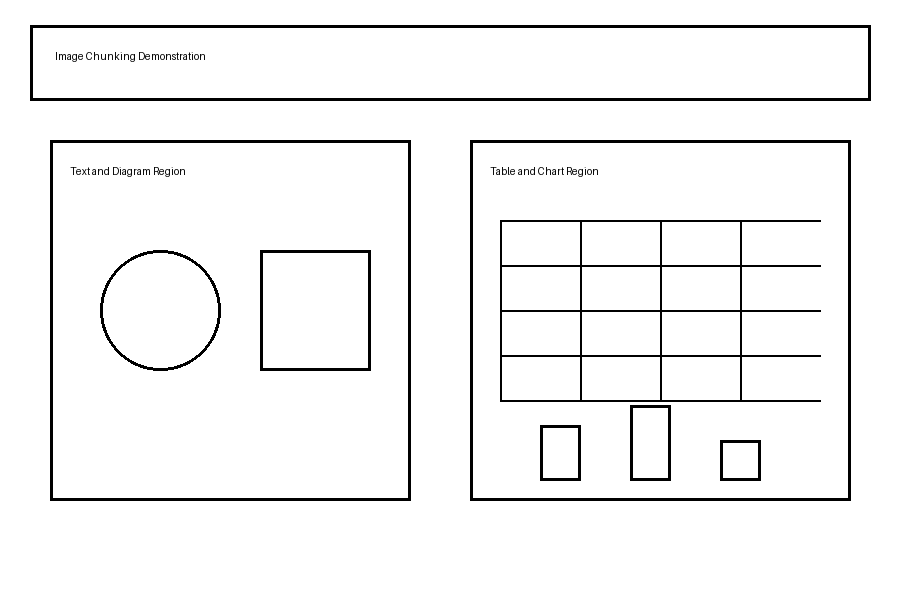

Saved: chunking_outputs/sample_image.png


In [24]:
def create_sample_image(
    width: int = 900,
    height: int = 600,
) -> Image.Image:
    image = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(image)

    draw.rectangle((30, 25, width - 30, 100), outline="black", width=3)
    draw.text((55, 50), "Image Chunking Demonstration", fill="black")

    draw.rectangle((50, 140, 410, 500), outline="black", width=3)
    draw.text((70, 165), "Text and Diagram Region", fill="black")
    draw.ellipse((100, 250, 220, 370), outline="black", width=3)
    draw.rectangle((260, 250, 370, 370), outline="black", width=3)

    draw.rectangle((470, 140, 850, 500), outline="black", width=3)
    draw.text((490, 165), "Table and Chart Region", fill="black")

    for row in range(5):
        y = 220 + row * 45
        draw.line((500, y, 820, y), fill="black", width=2)

    for col in range(4):
        x = 500 + col * 80
        draw.line((x, 220, x, 400), fill="black", width=2)

    draw.rectangle((540, 425, 580, 480), outline="black", width=3)
    draw.rectangle((630, 405, 670, 480), outline="black", width=3)
    draw.rectangle((720, 440, 760, 480), outline="black", width=3)

    return image


sample_image = create_sample_image()
sample_image_path = OUTPUT_DIR / "sample_image.png"
sample_image.save(sample_image_path)

display(sample_image)
print("Saved:", sample_image_path)

Total image chunks: 6
Chunk 1 | box=(0, 0, 330, 330) | path=chunking_outputs/image_chunks/image_chunk_01.png


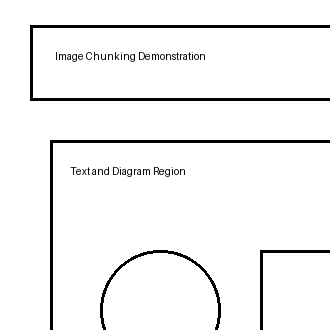

Chunk 2 | box=(270, 0, 630, 330) | path=chunking_outputs/image_chunks/image_chunk_02.png


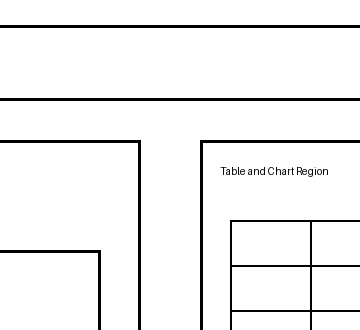

Chunk 3 | box=(570, 0, 900, 330) | path=chunking_outputs/image_chunks/image_chunk_03.png


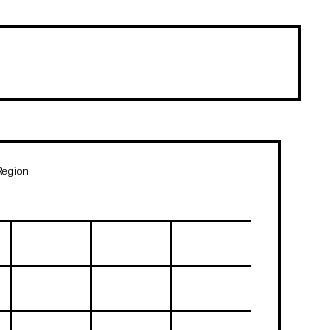

Chunk 4 | box=(0, 270, 330, 600) | path=chunking_outputs/image_chunks/image_chunk_04.png


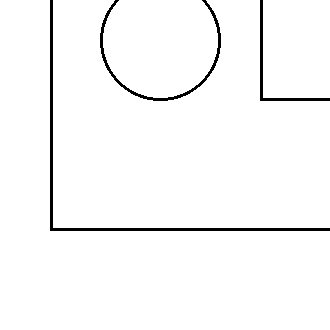

Chunk 5 | box=(270, 270, 630, 600) | path=chunking_outputs/image_chunks/image_chunk_05.png


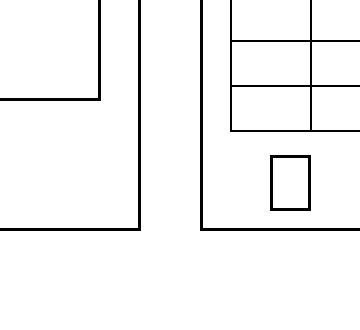

Chunk 6 | box=(570, 270, 900, 600) | path=chunking_outputs/image_chunks/image_chunk_06.png


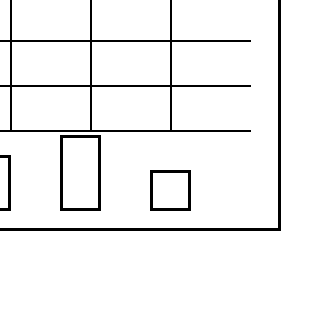

In [27]:
def chunk_image_into_tiles(
    image: Image.Image,
    output_dir: Path,
    rows: int = 2,
    columns: int = 3,
    overlap: int = 30,
) -> list[dict[str, Any]]:
    """Divide an image into overlapping grid tiles."""

    if rows <= 0 or columns <= 0:
        raise ValueError("rows and columns must be positive.")

    if overlap < 0:
        raise ValueError("overlap cannot be negative.")

    output_dir.mkdir(parents=True, exist_ok=True)

    width, height = image.size
    base_width = math.ceil(width / columns)
    base_height = math.ceil(height / rows)

    chunks = []
    chunk_id = 1

    for row in range(rows):
        for column in range(columns):
            x1 = max(
                0,
                column * base_width
                - (overlap if column > 0 else 0),
            )
            y1 = max(
                0,
                row * base_height
                - (overlap if row > 0 else 0),
            )
            x2 = min(
                width,
                (column + 1) * base_width
                + (overlap if column < columns - 1 else 0),
            )
            y2 = min(
                height,
                (row + 1) * base_height
                + (overlap if row < rows - 1 else 0),
            )

            tile = image.crop((x1, y1, x2, y2))
            tile_path = output_dir / f"image_chunk_{chunk_id:02d}.png"
            tile.save(tile_path)

            chunks.append(
                {
                    "chunk_id": chunk_id,
                    "bounding_box": (x1, y1, x2, y2),
                    "path": str(tile_path),
                    "image": tile,
                }
            )

            chunk_id += 1

    return chunks


image_chunks = chunk_image_into_tiles(
    image=sample_image,
    output_dir=OUTPUT_DIR / "image_chunks",
    rows=2,
    columns=3,
    overlap=30,
)

print("Total image chunks:", len(image_chunks))

for item in image_chunks:
    print(
        f"Chunk {item['chunk_id']} | "
        f"box={item['bounding_box']} | "
        f"path={item['path']}"
    )
    display(item["image"])

## Image-chunking decision

Use image chunking when:

- The image is high resolution
- Small details may disappear during resizing
- It contains many objects
- It contains small text
- Region-level retrieval is required
- The image is a large scan, map, diagram, or satellite image

Do not rely only on chunks when global relationships matter. A strong design may store both:

```text
Full image → global context
Image chunks → local detail
```

# Table Chunking Practical

Tables can be chunked by:

- Rows
- Overlapping rows
- Columns
- Category
- Entity
- Date or time range

Every chunk should preserve:

- Column names
- Primary or joining keys
- Table title or description
- Units
- Relevant metadata

In [28]:
sales_table = pd.DataFrame(
    [
        {
            "Order_ID": "O-101",
            "Product": "Laptop",
            "Category": "Electronics",
            "Region": "North",
            "Quantity": 2,
            "Revenue_USD": 2400,
        },
        {
            "Order_ID": "O-102",
            "Product": "Mouse",
            "Category": "Electronics",
            "Region": "South",
            "Quantity": 10,
            "Revenue_USD": 250,
        },
        {
            "Order_ID": "O-103",
            "Product": "Chair",
            "Category": "Furniture",
            "Region": "West",
            "Quantity": 4,
            "Revenue_USD": 800,
        },
        {
            "Order_ID": "O-104",
            "Product": "Desk",
            "Category": "Furniture",
            "Region": "East",
            "Quantity": 2,
            "Revenue_USD": 1100,
        },
        {
            "Order_ID": "O-105",
            "Product": "Keyboard",
            "Category": "Electronics",
            "Region": "North",
            "Quantity": 6,
            "Revenue_USD": 540,
        },
        {
            "Order_ID": "O-106",
            "Product": "Notebook",
            "Category": "Stationery",
            "Region": "South",
            "Quantity": 20,
            "Revenue_USD": 120,
        },
        {
            "Order_ID": "O-107",
            "Product": "Pen Set",
            "Category": "Stationery",
            "Region": "West",
            "Quantity": 15,
            "Revenue_USD": 90,
        },
        {
            "Order_ID": "O-108",
            "Product": "Monitor",
            "Category": "Electronics",
            "Region": "East",
            "Quantity": 3,
            "Revenue_USD": 900,
        },
    ]
)

display(sales_table)

,Order_ID,Product,Category,Region,Quantity,Revenue_USD
0,O-101,Laptop,Electronics,North,2,2400
1,O-102,Mouse,Electronics,South,10,250
2,O-103,Chair,Furniture,West,4,800
3,O-104,Desk,Furniture,East,2,1100
4,O-105,Keyboard,Electronics,North,6,540
5,O-106,Notebook,Stationery,South,20,120
6,O-107,Pen Set,Stationery,West,15,90
7,O-108,Monitor,Electronics,East,3,900


In [29]:
def chunk_table_by_rows(
    table: pd.DataFrame,
    chunk_size: int,
    overlap: int = 0,
) -> list[pd.DataFrame]:
    if chunk_size <= 0:
        raise ValueError("chunk_size must be greater than zero.")

    if overlap < 0 or overlap >= chunk_size:
        raise ValueError("overlap must satisfy 0 <= overlap < chunk_size.")

    step = chunk_size - overlap
    chunks = []

    for start in range(0, len(table), step):
        chunk = table.iloc[start:start + chunk_size].copy()

        if chunk.empty:
            break

        chunks.append(chunk)

        if start + chunk_size >= len(table):
            break

    return chunks


row_chunks = chunk_table_by_rows(
    sales_table,
    chunk_size=3,
    overlap=1,
)

for index, chunk in enumerate(row_chunks, start=1):
    print(f"Row Chunk {index}")
    display(chunk)

Row Chunk 1


,Order_ID,Product,Category,Region,Quantity,Revenue_USD
0,O-101,Laptop,Electronics,North,2,2400
1,O-102,Mouse,Electronics,South,10,250
2,O-103,Chair,Furniture,West,4,800


Row Chunk 2


,Order_ID,Product,Category,Region,Quantity,Revenue_USD
2,O-103,Chair,Furniture,West,4,800
3,O-104,Desk,Furniture,East,2,1100
4,O-105,Keyboard,Electronics,North,6,540


Row Chunk 3


,Order_ID,Product,Category,Region,Quantity,Revenue_USD
4,O-105,Keyboard,Electronics,North,6,540
5,O-106,Notebook,Stationery,South,20,120
6,O-107,Pen Set,Stationery,West,15,90


Row Chunk 4


,Order_ID,Product,Category,Region,Quantity,Revenue_USD
6,O-107,Pen Set,Stationery,West,15,90
7,O-108,Monitor,Electronics,East,3,900


## Category-based table chunking

This is often more meaningful than arbitrary row groups when the table contains clear business categories.

In [30]:
category_chunks = {
    category: group.reset_index(drop=True)
    for category, group in sales_table.groupby("Category")
}

for category, chunk in category_chunks.items():
    print(f"Category Chunk: {category}")
    display(chunk)

Category Chunk: Electronics


,Order_ID,Product,Category,Region,Quantity,Revenue_USD
0,O-101,Laptop,Electronics,North,2,2400
1,O-102,Mouse,Electronics,South,10,250
2,O-105,Keyboard,Electronics,North,6,540
3,O-108,Monitor,Electronics,East,3,900


Category Chunk: Furniture


,Order_ID,Product,Category,Region,Quantity,Revenue_USD
0,O-103,Chair,Furniture,West,4,800
1,O-104,Desk,Furniture,East,2,1100


Category Chunk: Stationery


,Order_ID,Product,Category,Region,Quantity,Revenue_USD
0,O-106,Notebook,Stationery,South,20,120
1,O-107,Pen Set,Stationery,West,15,90


## Column-based table chunking

For a very wide table, preserve a shared key such as `Order_ID` in every column group.

In [31]:
column_chunks = {
    "product_information": sales_table[
        ["Order_ID", "Product", "Category"]
    ],
    "sales_metrics": sales_table[
        ["Order_ID", "Quantity", "Revenue_USD"]
    ],
    "location_information": sales_table[
        ["Order_ID", "Region"]
    ],
}

for name, chunk in column_chunks.items():
    print(name)
    display(chunk)

product_information


,Order_ID,Product,Category
0,O-101,Laptop,Electronics
1,O-102,Mouse,Electronics
2,O-103,Chair,Furniture
3,O-104,Desk,Furniture
4,O-105,Keyboard,Electronics
5,O-106,Notebook,Stationery
6,O-107,Pen Set,Stationery
7,O-108,Monitor,Electronics


sales_metrics


,Order_ID,Quantity,Revenue_USD
0,O-101,2,2400
1,O-102,10,250
2,O-103,4,800
3,O-104,2,1100
4,O-105,6,540
5,O-106,20,120
6,O-107,15,90
7,O-108,3,900


location_information


,Order_ID,Region
0,O-101,North
1,O-102,South
2,O-103,West
3,O-104,East
4,O-105,North
5,O-106,South
6,O-107,West
7,O-108,East


## Convert a table chunk into embedding-friendly text

Embedding models generally consume text. Therefore, include column names instead of sending raw values without labels.

In [32]:
def serialize_table_chunk(
    table: pd.DataFrame,
    table_name: str,
) -> str:
    records = [f"Table: {table_name}"]

    for row_number, (_, row) in enumerate(
        table.iterrows(),
        start=1,
    ):
        fields = [
            f"{column}: {row[column]}"
            for column in table.columns
        ]
        records.append(
            f"Row {row_number}:\n" + "\n".join(fields)
        )

    return "\n\n".join(records)


serialized_chunk = serialize_table_chunk(
    row_chunks[0],
    table_name="Sales Orders",
)

print(serialized_chunk)

Table: Sales Orders

Row 1:
Order_ID: O-101
Product: Laptop
Category: Electronics
Region: North
Quantity: 2
Revenue_USD: 2400

Row 2:
Order_ID: O-102
Product: Mouse
Category: Electronics
Region: South
Quantity: 10
Revenue_USD: 250

Row 3:
Order_ID: O-103
Product: Chair
Category: Furniture
Region: West
Quantity: 4
Revenue_USD: 800


## When not to embed a table

If the table is stored in SQL and the user asks exact questions such as totals, filters, averages, or joins, prefer:

```text
User question
      ↓
SQL generation or query construction
      ↓
Exact database rows or aggregation
      ↓
LLM explanation
```

Vector retrieval is more suitable when the table is extracted from a PDF, semantic matching is required, or exact database querying is unavailable.

# Common Chunking Mistakes

1. Choosing chunk size without evaluating retrieval
2. Creating chunks that are too small
3. Creating chunks that are too large
4. Adding excessive overlap
5. Splitting headings away from their content
6. Splitting tables without preserving headers
7. Splitting code in the middle of functions or classes
8. Removing useful metadata
9. Using semantic or agentic chunking without comparing a simpler baseline
10. Assuming one strategy works for every data type